# Probability Space

A **probability space** is a triple $(\Omega,\mathcal{F},P)$ consisting of:

1. A **sample space** $\Omega$, the set of all possible outcomes.
2. A **$\sigma$-algebra** $\mathcal{F}$ of subsets of $\Omega$, whose elements are called events.
3. A **probability measure** $P:\mathcal{F}\to[0,1]$.

A collection $\mathcal{F}\subseteq 2^\Omega$ is called a **$\sigma$-algebra** if:

- $\Omega\in\mathcal{F}$;
- $A\in\mathcal{F}\implies A^c\in\mathcal{F}$;
- if $A_1,A_2,\ldots\in\mathcal{F}$, then $\bigcup_{n=1}^{\infty}A_n\in\mathcal{F}$.

A function $P:\mathcal{F}\to[0,1]$ is called a **probability measure** if:

- $P(\Omega)=1$;
- for every pairwise disjoint sequence $A_1,A_2,\ldots\in\mathcal{F}$,
  $$
  P\!\left(\bigcup_{n=1}^{\infty}A_n\right)
  =
  \sum_{n=1}^{\infty}P(A_n).
  $$

From the axioms one obtains the basic properties

$$
P(A^c)=1-P(A),
$$

$$
A\subseteq B \quad\Longrightarrow\quad P(A)\le P(B),
$$

$$
P(A\cup B)=P(A)+P(B)-P(A\cap B).
$$

# Classical Probability Model

The **classical model** is defined by the following assumptions:

- $\Omega=\{\omega_1,\ldots,\omega_n\}$ is a finite sample space;
- $\mathcal{F}=2^\Omega$;
- all elementary outcomes are equally likely:
  $$
  P(\{\omega_i\})=\frac1n,\qquad i=1,\ldots,n.
  $$

Consequently, for every event $A\subseteq\Omega$,

$$
P(A)=\frac{|A|}{|\Omega|}.
$$

More generally, if $\Omega$ is finite or countable and $\mathcal{F}=2^\Omega$, then a probability measure is completely determined by the probabilities of the elementary outcomes $P(\{\omega\})$, $\omega\in\Omega$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb, pi

np.random.seed(42)

## Example: Die Roll

Consider one fair die roll. Then $\Omega=\{1,2,3,4,5,6\}$, $\mathcal F=2^\Omega$, and $P(\{\omega\})=1/6$ for every $\omega\in\Omega$.

Let $A=\{\text{the result is even}\}=\{2,4,6\}$. Then $P(A)=|A|/|\Omega|=3/6=1/2$.

In [6]:
N = 10_000

rolls = np.random.randint(1, 7, size=N)
event_even = (rolls % 2 == 0)

empirical_prob = event_even.mean()
theoretical_prob = 1/2

print("Empirical probability:", empirical_prob)
print("Theoretical probability:", theoretical_prob)

Empirical probability: 0.4962
Theoretical probability: 0.5


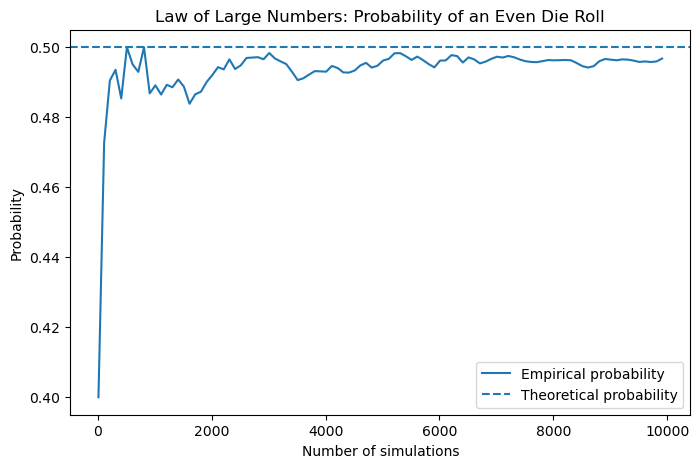

In [7]:
sample_sizes = np.arange(10, N + 1, 100)
running_probs = [event_even[:n].mean() for n in sample_sizes]

plt.figure(figsize=(8, 5))
plt.plot(sample_sizes, running_probs, label="Empirical probability")
plt.axhline(theoretical_prob, linestyle="--", label="Theoretical probability")
plt.xlabel("Number of simulations")
plt.ylabel("Probability")
plt.title("Law of Large Numbers: Probability of an Even Die Roll")
plt.legend()
plt.show()

## Example: Two Dice

Roll two fair dice. Then $\Omega=\{1,\ldots,6\}^2$ and $|\Omega|=36$. Let $A=\{\text{the sum is }7\}$. The favorable outcomes are $(1,6),(2,5),(3,4),(4,3),(5,2),(6,1)$, hence $|A|=6$ and $P(A)=6/36=1/6$.

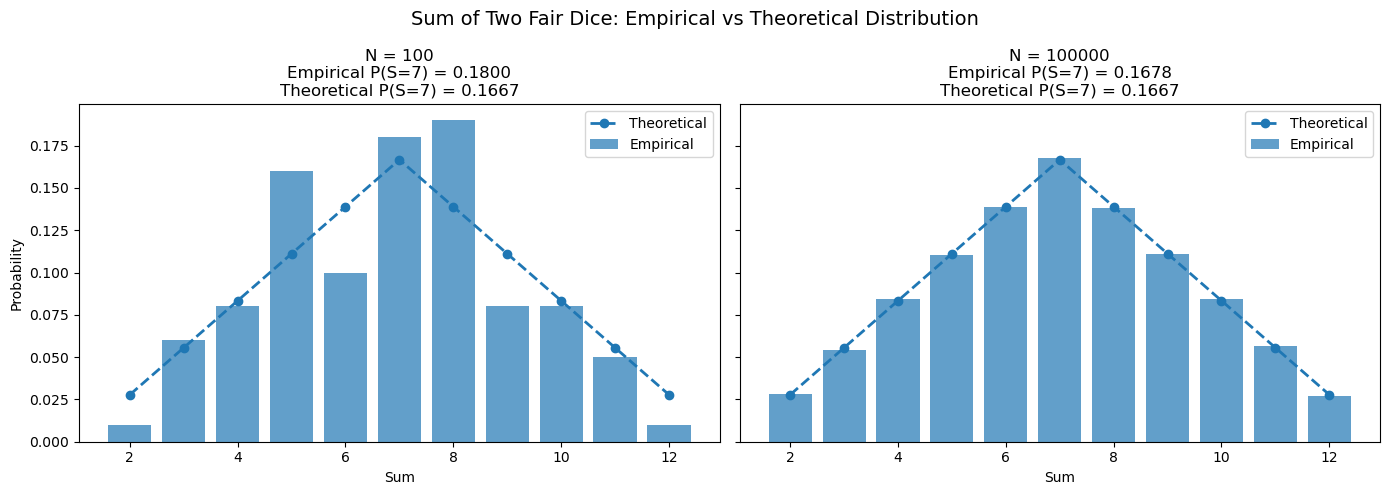

Theoretical P(S=7) = 0.166667
N=   100: Empirical P(S=7) = 0.180000
N=100000: Empirical P(S=7) = 0.167760


In [21]:
N_small = 100
N_large = 100_000

# --------------------------
# Small sample
# --------------------------

die1 = np.random.randint(1, 7, size=N_small)
die2 = np.random.randint(1, 7, size=N_small)

sums_small = die1 + die2

empirical_small = np.mean(sums_small == 7)

values_small, counts_small = np.unique(sums_small, return_counts=True)

probs_small = np.zeros(11)

for v, c in zip(values_small, counts_small):
    probs_small[v - 2] = c / N_small

# --------------------------
# Large sample
# --------------------------

die1 = np.random.randint(1, 7, size=N_large)
die2 = np.random.randint(1, 7, size=N_large)

sums_large = die1 + die2

empirical_large = np.mean(sums_large == 7)

values_large, counts_large = np.unique(sums_large, return_counts=True)

probs_large = np.zeros(11)

for v, c in zip(values_large, counts_large):
    probs_large[v - 2] = c / N_large

# --------------------------
# Theoretical distribution
# --------------------------

x = np.arange(2, 13)

theoretical = np.array([
    1, 2, 3, 4, 5, 6,
    5, 4, 3, 2, 1
]) / 36

theoretical_prob = 1 / 6

# --------------------------
# Plot
# --------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].bar(x, probs_small, alpha=0.7, label="Empirical")
axes[0].plot(x, theoretical, "o--", linewidth=2, label="Theoretical")

axes[0].set_title(
    f"N = {N_small}\n"
    f"Empirical P(S=7) = {empirical_small:.4f}\n"
    f"Theoretical P(S=7) = {theoretical_prob:.4f}"
)

axes[0].set_xlabel("Sum")
axes[0].set_ylabel("Probability")
axes[0].legend()

axes[1].bar(x, probs_large, alpha=0.7, label="Empirical")
axes[1].plot(x, theoretical, "o--", linewidth=2, label="Theoretical")

axes[1].set_title(
    f"N = {N_large}\n"
    f"Empirical P(S=7) = {empirical_large:.4f}\n"
    f"Theoretical P(S=7) = {theoretical_prob:.4f}"
)

axes[1].set_xlabel("Sum")
axes[1].legend()

plt.suptitle("Sum of Two Fair Dice: Empirical vs Theoretical Distribution",
             fontsize=14)

plt.tight_layout()
plt.show()

print(f"Theoretical P(S=7) = {theoretical_prob:.6f}")
print(f"N={N_small:>6}: Empirical P(S=7) = {empirical_small:.6f}")
print(f"N={N_large:>6}: Empirical P(S=7) = {empirical_large:.6f}")

## Example: Cards

Suppose we draw cards from a standard deck of $52$ cards. The probability of drawing an ace is $4/52=1/13$.

If two cards are drawn without replacement, then the probability that both cards are aces is

$$
\frac{4}{52}\cdot\frac{3}{51}.
$$

In [22]:
N = 100_000

# Represent deck by 1 for ace and 0 for non-ace
deck = np.array([1]*4 + [0]*48)

successes = 0

for _ in range(N):
    draw = np.random.choice(deck, size=2, replace=False)
    if draw.sum() == 2:
        successes += 1

empirical_prob = successes / N
theoretical_prob = (4/52) * (3/51)

print("Empirical probability:", empirical_prob)
print("Theoretical probability:", theoretical_prob)

Empirical probability: 0.00475
Theoretical probability: 0.004524886877828055


# Geometric Probability Model

Let $\Omega\subseteq\mathbb{R}^d$ be a measurable set with finite Lebesgue measure $\mu(\Omega)<\infty$. The **geometric probability model** is defined by

$$
\mathcal{F}=\{A\subseteq\Omega:\;A\text{ is measurable}\},
$$

and

$$
P(A)=\frac{\mu(A)}{\mu(\Omega)}, \qquad A\in\mathcal{F}.
$$

Thus, probabilities are proportional to geometric quantities such as length, area, or volume. Informally, a random point is chosen uniformly from $\Omega$, and the probability of an event is the fraction of the total measure occupied by the corresponding region.

## Example: Bus Problem

Suppose you and a bus arrive independently and uniformly at random between $12:00$ and $13:00$. The bus waits for $15$ minutes before leaving, and you also wait $15$ minutes if the bus has not arrived yet.

After rescaling time to $[0,1]$, $15$ minutes corresponds to $1/4$. You catch the bus if $|X-Y|\le 1/4$. The bad region consists of two triangles with total area $2\cdot (3/4)^2/2=9/16$. Therefore,

$$
P(\text{catch the bus})=1-\frac{9}{16}=\frac{7}{16}.
$$

Empirical probability: 0.43745
Theoretical probability: 0.4375


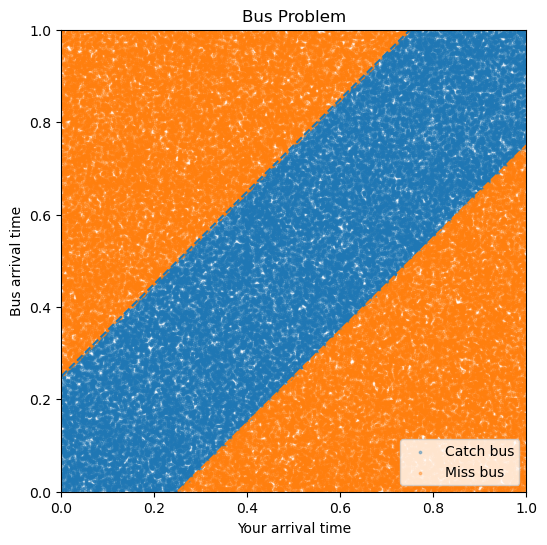

In [27]:
N = 100_000

X = np.random.random(N)  # your arrival time
Y = np.random.random(N)  # bus arrival time

event = np.abs(X - Y) <= 1/4

empirical_prob = event.mean()
theoretical_prob = 7/16

print("Empirical probability:", empirical_prob)
print("Theoretical probability:", theoretical_prob)

plt.figure(figsize=(6, 6))
plt.scatter(X[event], Y[event], s=3, alpha=0.4, label="Catch bus")
plt.scatter(X[~event], Y[~event], s=3, alpha=0.4, label="Miss bus")

x = np.linspace(0, 1, 300)
plt.plot(x, x + 1/4, linestyle="--")
plt.plot(x, x - 1/4, linestyle="--")

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("Your arrival time")
plt.ylabel("Bus arrival time")
plt.title("Bus Problem")
plt.legend()
plt.show()

## Bertrand's Paradox

Consider a circle of radius $R$. We choose a chord at random and ask

$$
P(\text{the chord is longer than the side of an inscribed equilateral triangle})=?
$$

The side length of an inscribed equilateral triangle is $\sqrt{3}R$. If $d$ is the distance from the center of the circle to the chord, then the chord length is $L=2\sqrt{R^2-d^2}$. Hence

$$
L>\sqrt{3}R
\quad\Longleftrightarrow\quad
d<\frac{R}{2}.
$$

The ambiguity is that the phrase "choose a chord at random" can mean different things.

**Method 1: random endpoints.** Choose two points independently and uniformly on the circumference and join them by a chord. This gives

$$
P\left(L>\sqrt{3}R\right)=\frac13.
$$

**Method 2: random distance from the center.** Choose the distance $d$ uniformly from $[0,R]$, then choose the direction of the chord uniformly at random. Since the chord is long exactly when $d<R/2$, this gives

$$
P\left(L>\sqrt{3}R\right)=\frac12.
$$

**Method 3: random midpoint.** Choose the midpoint of the chord uniformly from the disk. The chord is long exactly when the midpoint lies inside the disk of radius $R/2$, so this gives

$$
P\left(L>\sqrt{3}R\right)
=
\frac{\pi(R/2)^2}{\pi R^2}
=
\frac14.
$$

Thus the same informal question gives three different answers:

$$
\frac13,\qquad \frac12,\qquad \frac14.
$$

This is Bertrand's paradox. It shows that a probability problem is not well-defined until the probability space, or equivalently the random mechanism, is precisely specified.

Bertrand's Paradox

Method 1: Random endpoints
Empirical probability:   0.3299
Theoretical probability: 0.3333

Method 2: Random distance from center
Empirical probability:   0.5006
Theoretical probability: 0.5000

Method 3: Random midpoint in disk
Empirical probability:   0.2509
Theoretical probability: 0.2500


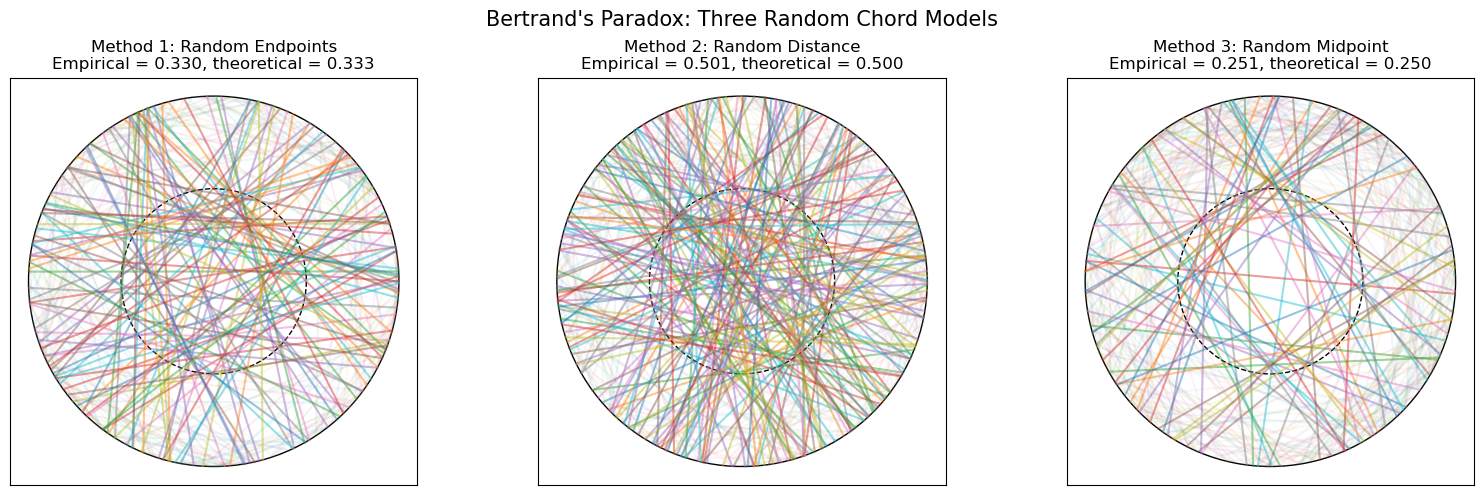

In [46]:
R = 1
N = 20_000
M = 300   # number of chords drawn in the plots

threshold = np.sqrt(3) * R

# -------------------------------------------------
# Method 1: Random endpoints on the circumference
# -------------------------------------------------

theta1 = np.random.uniform(0, 2*np.pi, size=N)
theta2 = np.random.uniform(0, 2*np.pi, size=N)

x1_a = R * np.cos(theta1)
y1_a = R * np.sin(theta1)

x2_a = R * np.cos(theta2)
y2_a = R * np.sin(theta2)

lengths_a = np.sqrt((x1_a - x2_a)**2 + (y1_a - y2_a)**2)
event_a = lengths_a > threshold

empirical_a = event_a.mean()
theoretical_a = 1/3

# -------------------------------------------------
# Method 2: Random distance from center
# -------------------------------------------------

d = np.random.uniform(0, R, size=N)
theta = np.random.uniform(0, 2*np.pi, size=N)

nx = np.cos(theta)
ny = np.sin(theta)

vx = -np.sin(theta)
vy = np.cos(theta)

half_lengths = np.sqrt(R**2 - d**2)

mid_x_b = d * nx
mid_y_b = d * ny

x1_b = mid_x_b + half_lengths * vx
y1_b = mid_y_b + half_lengths * vy

x2_b = mid_x_b - half_lengths * vx
y2_b = mid_y_b - half_lengths * vy

lengths_b = 2 * half_lengths
event_b = lengths_b > threshold

empirical_b = event_b.mean()
theoretical_b = 1/2

# -------------------------------------------------
# Method 3: Random midpoint in the disk
# -------------------------------------------------

theta = np.random.uniform(0, 2*np.pi, size=N)
rho = R * np.sqrt(np.random.uniform(0, 1, size=N))

mid_x_c = rho * np.cos(theta)
mid_y_c = rho * np.sin(theta)

d = rho

vx = -np.sin(theta)
vy = np.cos(theta)

half_lengths = np.sqrt(R**2 - d**2)

x1_c = mid_x_c + half_lengths * vx
y1_c = mid_y_c + half_lengths * vy

x2_c = mid_x_c - half_lengths * vx
y2_c = mid_y_c - half_lengths * vy

lengths_c = 2 * half_lengths
event_c = lengths_c > threshold

empirical_c = event_c.mean()
theoretical_c = 1/4

# -------------------------------------------------
# Print comparison
# -------------------------------------------------

print("Bertrand's Paradox")
print()
print(f"Method 1: Random endpoints")
print(f"Empirical probability:   {empirical_a:.4f}")
print(f"Theoretical probability: {theoretical_a:.4f}")
print()
print(f"Method 2: Random distance from center")
print(f"Empirical probability:   {empirical_b:.4f}")
print(f"Theoretical probability: {theoretical_b:.4f}")
print()
print(f"Method 3: Random midpoint in disk")
print(f"Empirical probability:   {empirical_c:.4f}")
print(f"Theoretical probability: {theoretical_c:.4f}")

# -------------------------------------------------
# Plot all methods side by side
# -------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

methods = [
    (
        axes[0],
        x1_a, y1_a, x2_a, y2_a,
        event_a,
        "Method 1: Random Endpoints",
        empirical_a,
        theoretical_a
    ),
    (
        axes[1],
        x1_b, y1_b, x2_b, y2_b,
        event_b,
        "Method 2: Random Distance",
        empirical_b,
        theoretical_b
    ),
    (
        axes[2],
        x1_c, y1_c, x2_c, y2_c,
        event_c,
        "Method 3: Random Midpoint",
        empirical_c,
        theoretical_c
    )
]

for ax, x1, y1, x2, y2, event, title, empirical, theoretical in methods:
    circle = plt.Circle((0, 0), R, fill=False)
    inner_circle = plt.Circle((0, 0), R/2, fill=False, linestyle="--")

    ax.add_patch(circle)
    ax.add_patch(inner_circle)

    for i in range(M):
        if event[i]:
            ax.plot([x1[i], x2[i]], [y1[i], y2[i]], alpha=0.45)
        else:
            ax.plot([x1[i], x2[i]], [y1[i], y2[i]], alpha=0.08)

    ax.set_aspect("equal")
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)

    ax.set_title(
        title
        + "\n"
        + f"Empirical = {empirical:.3f}, theoretical = {theoretical:.3f}"
    )

    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle(
    "Bertrand's Paradox: Three Random Chord Models",
    fontsize=15
)

plt.tight_layout()
plt.show()

# Bernoulli Scheme

Fix $n\in\mathbb{N}$ and $p\in(0,1)$. The **Bernoulli scheme** consists of $n$ independent trials, each resulting in success ($1$) with probability $p$ and failure ($0$) with probability $1-p$.

The sample space is

$$
\Omega=\{(x_1,\ldots,x_n):x_i\in\{0,1\}\},
$$

so that $|\Omega|=2^n$.

For an outcome $\omega=(x_1,\ldots,x_n)$,

$$
P(\{\omega\})
=
p^{\sum_{i=1}^{n}x_i}
(1-p)^{\,n-\sum_{i=1}^{n}x_i}.
$$

The random variable

$$
S_n=\sum_{i=1}^{n}x_i
$$

counts the number of successes.

## Example: Binomial Distribution

Let $S_n$ be the number of successes in $n$ independent Bernoulli trials with success probability $p$. Then

$$
P(S_n=m)=\binom{n}{m}p^m(1-p)^{n-m},\qquad m=0,1,\ldots,n.
$$

For example, if a fair coin is tossed $10$ times, then the probability of exactly $5$ heads is

$$
P(S_{10}=5)=\binom{10}{5}\left(\frac12\right)^{10}.
$$

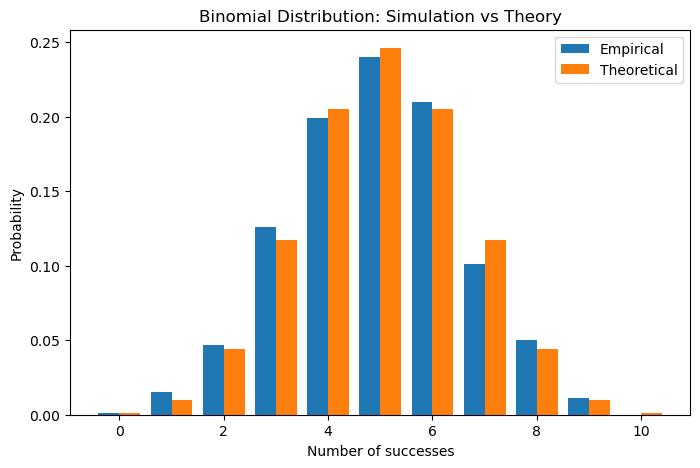

In [33]:
N = 1000

samples = np.random.binomial(n, p, size=N)

values = np.arange(n + 1)
empirical_probs = np.array([np.mean(samples == k) for k in values])
theoretical_probs = np.array([comb(n, k) * p**k * (1-p)**(n-k) for k in values])

plt.figure(figsize=(8, 5))
plt.bar(values - 0.2, empirical_probs, width=0.4, label="Empirical")
plt.bar(values + 0.2, theoretical_probs, width=0.4, label="Theoretical")
plt.xlabel("Number of successes")
plt.ylabel("Probability")
plt.title("Binomial Distribution: Simulation vs Theory")
plt.legend()
plt.show()

## Example: At Least One Success

If $S_n\sim\mathrm{Bin}(n,p)$, then

$$
P(S_n\ge 1)=1-P(S_n=0)=1-(1-p)^n.
$$

This formula is often easier than adding many probabilities.

## Example: Most Probable Number of Successes

If $S_n\sim\mathrm{Bin}(n,p)$, then a most probable value is

$$
m=\lfloor (n+1)p\rfloor.
$$

If $(n+1)p$ is an integer, then both $(n+1)p-1$ and $(n+1)p$ are modes.

Mode by formula: 6
Mode by computation: 6


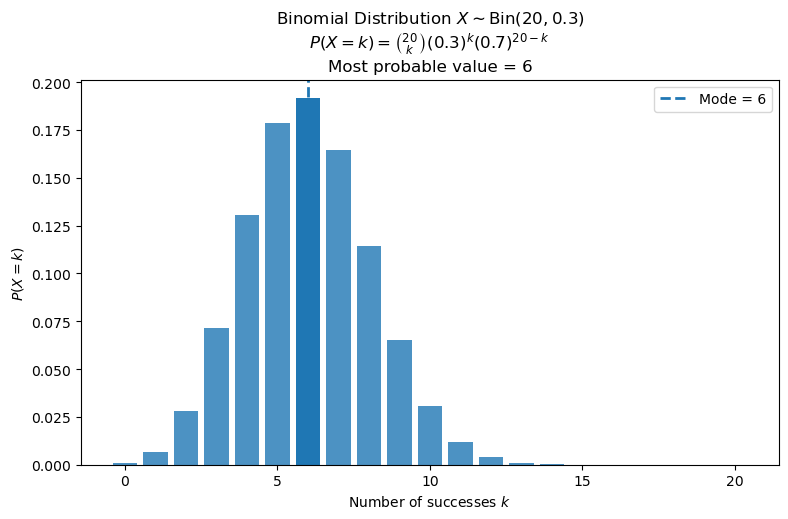

In [38]:
from math import comb
import numpy as np
import matplotlib.pyplot as plt

n = 20
p = 0.3

values = np.arange(n + 1)

probs = np.array([
    comb(n, k) * p**k * (1-p)**(n-k)
    for k in values
])

mode_formula = int(np.floor((n + 1) * p))
mode_computed = values[np.argmax(probs)]

print("Mode by formula:", mode_formula)
print("Mode by computation:", mode_computed)

plt.figure(figsize=(9, 5))

bars = plt.bar(values, probs, alpha=0.8)

# Highlight the mode
bars[mode_formula].set_alpha(1)

plt.axvline(
    mode_formula,
    linestyle="--",
    linewidth=2,
    label=f"Mode = {mode_formula}"
)

plt.xlabel("Number of successes $k$")
plt.ylabel(r"$P(X=k)$")

plt.title(
    r"Binomial Distribution $X\sim\mathrm{Bin}(20,0.3)$"
    "\n"
    r"$P(X=k)=\binom{20}{k}(0.3)^k(0.7)^{20-k}$"
    "\n"
    rf"Most probable value = {mode_formula}"
)

plt.legend()
plt.show()

# Independence of Events

Let $A,B\in\mathcal{F}$. The events $A$ and $B$ are called **independent** if

$$
P(A\cap B)=P(A)P(B).
$$

Equivalently, whenever $P(B)>0$,

$$
P(A\mid B)=P(A).
$$

A collection of events $A_1,\ldots,A_n$ is called **pairwise independent** if

$$
P(A_i\cap A_j)=P(A_i)P(A_j),
\qquad i\neq j.
$$

The events $A_1,\ldots,A_n$ are called **mutually independent** if for every subset $I\subseteq\{1,\ldots,n\}$ with $|I|\ge 2$,

$$
P\!\left(\bigcap_{i\in I}A_i\right)
=
\prod_{i\in I}P(A_i).
$$

Mutual independence implies pairwise independence, but the converse is generally false.

## Example: Dependent Events

Draw two cards without replacement from a standard deck. Let $A=\{\text{first card is an ace}\}$ and $B=\{\text{second card is an ace}\}$. Then

$$
P(A)=\frac4{52},\qquad P(B)=\frac4{52},
$$

but

$$
P(A\cap B)=\frac4{52}\cdot\frac3{51}\neq \frac4{52}\cdot\frac4{52}.
$$

Therefore, $A$ and $B$ are not independent.

In [39]:
N = 100_000

deck = np.array([1]*4 + [0]*48)

A_values = []
B_values = []

for _ in range(N):
    draw = np.random.choice(deck, size=2, replace=False)
    A_values.append(draw[0] == 1)
    B_values.append(draw[1] == 1)

A = np.array(A_values)
B = np.array(B_values)

print("P(A):", A.mean())
print("P(B):", B.mean())
print("P(A and B):", np.mean(A & B))
print("P(A)P(B):", A.mean() * B.mean())

P(A): 0.07821
P(B): 0.07597
P(A and B): 0.00465
P(A)P(B): 0.0059416137


## Example: Pairwise but Not Mutual Independence

Toss two fair coins and write the outcomes as $X,Y\in\{0,1\}$. Define three events

$$
A=\{X=0\},\qquad B=\{Y=0\},\qquad C=\{X=Y\}.
$$

Then $A$, $B$, and $C$ are pairwise independent. However,

$$
P(A\cap B\cap C)=\frac14,
$$

while

$$
P(A)P(B)P(C)=\frac12\cdot\frac12\cdot\frac12=\frac18.
$$

Therefore, the events are pairwise independent but not mutually independent.

# How Are Random Numbers Generated by a Computer?

Throughout this course we will frequently use Python functions such as

```python
np.random.random()
np.random.randint()
np.random.binomial()
```

to simulate random experiments. This naturally raises the following question:

> How can a computer generate random numbers if a computer is a deterministic machine?

---

## True Randomness vs Pseudorandomness

A computer executes a sequence of deterministic instructions. If we start a program twice with exactly the same initial conditions, it will perform exactly the same calculations and produce exactly the same output.

For this reason, most "random" numbers generated by a computer are not truly random. Instead, they are **pseudorandom numbers**.

A pseudorandom number generator (PRNG) is a deterministic algorithm that produces a sequence of numbers that behaves *as if* it were random.

Given an initial value called a **seed**, the generator produces

$$
x_0,x_1,x_2,\ldots
$$

according to a deterministic rule

$$
x_{n+1}=f(x_n).
$$

If the same seed is used again, exactly the same sequence will be generated.

For example:

```python
import numpy as np

np.random.seed(42)

print(np.random.random())
print(np.random.random())
print(np.random.random())
```

Running this code twice produces exactly the same numbers.

---

## Why Does This Work?

Although pseudorandom numbers are generated deterministically, good generators are designed so that their outputs satisfy many statistical properties expected from genuinely random sequences.

For practical purposes, the sequence appears random:

- frequencies are approximately correct;
- correlations are extremely small;
- patterns are difficult to detect;
- many statistical tests cannot distinguish the sequence from true randomness.

As a result, pseudorandom generators are sufficient for most scientific simulations, machine learning algorithms, statistical experiments, computer graphics, and video games.

---

## How Difficult Is It to Generate Truly Random Numbers?

Generating *true* randomness is surprisingly difficult.

A computer by itself cannot create randomness from nothing because its internal operations are deterministic.

To obtain genuine randomness, we must rely on unpredictable physical phenomena such as:

- radioactive decay;
- thermal noise in electronic circuits;
- atmospheric noise;
- photon arrival times;
- quantum measurements.

Such devices are called **hardware random number generators (HRNGs)**.

For example, some modern processors contain dedicated hardware that measures microscopic physical noise and converts it into random bits.

---

## Why Is True Randomness Important?

For many simulations, pseudorandom numbers are perfectly adequate.

However, some applications require unpredictability rather than merely statistical randomness.

Examples include:

- cryptography;
- secure communications;
- online banking;
- digital signatures;
- password generation;
- blockchain technologies;
- military systems.

Suppose a cryptographic system generates passwords using a predictable pseudorandom generator. If an attacker discovers the algorithm and the seed, every future password can be predicted.

For this reason, cryptographic systems often combine pseudorandom generators with physical sources of randomness.

---

## Randomness and Monte Carlo Methods

One of the most important applications of random numbers is **Monte Carlo simulation**.

The basic idea is simple:

1. Generate many random outcomes.
2. Compute the quantity of interest for each outcome.
3. Average the results.

For example, to estimate

$$
P(A),
$$

we can simulate the experiment many times and compute

$$
\hat P(A)
=
\frac{\text{number of times }A\text{ occurs}}
     {\text{number of simulations}}.
$$

The Law of Large Numbers guarantees that

$$
\hat P(A)\to P(A)
\qquad\text{as}\qquad
N\to\infty.
$$

This principle is used throughout science and engineering.

---

## Random Numbers in Real Life

Random number generators play a crucial role in many modern technologies:

- weather forecasting;
- machine learning;
- artificial intelligence;
- computer graphics and animation;
- risk analysis in finance;
- epidemiological modeling;
- nuclear physics;
- cryptography and cybersecurity;
- simulation of communication networks;
- reliability analysis of complex systems.

Many scientific problems are so complicated that exact calculations are impossible, while Monte Carlo simulations using random numbers provide accurate approximations.

---

## Historical Remark

During the 1940s, scientists working on the Manhattan Project needed large quantities of random numbers to simulate neutron transport inside nuclear reactors.

This led to the development of the **Monte Carlo method**, named after the famous casino in Monaco.

Today Monte Carlo methods are among the most powerful computational tools in mathematics, statistics, physics, engineering, finance, and data science.